<a href="https://colab.research.google.com/github/zappolag/python-data-cleaning-pipeline/blob/main/automated_excel_reporting_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np

data = {
    "Employee": ["Anna","Bob","Chris","Dana","Eva"],
    "Department": ["Sales","Sales","IT","IT","Finance"],
    "Hours": [40,45,38,50,42],
    "Hourly_Rate": [30,28,45,50,35],
    "Status": ["Complete","Complete","Complete","Missing","Complete"]
}

df = pd.DataFrame(data)

df

,Employee,Department,Hours,Hourly_Rate,Status
0,Anna,Sales,40,30,Complete
1,Bob,Sales,45,28,Complete
2,Chris,IT,38,45,Complete
3,Dana,IT,50,50,Missing
4,Eva,Finance,42,35,Complete


In [30]:
df.loc[3,"Hours"] = np.nan

df

,Employee,Department,Hours,Hourly_Rate,Status
0,Anna,Sales,40.0,30,Complete
1,Bob,Sales,45.0,28,Complete
2,Chris,IT,38.0,45,Complete
3,Dana,IT,NaN,50,Missing
4,Eva,Finance,42.0,35,Complete


In [31]:
#inspect data
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee     5 non-null      object 
 1   Department   5 non-null      object 
 2   Hours        4 non-null      float64
 3   Hourly_Rate  5 non-null      int64  
 4   Status       5 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 332.0+ bytes


,0
Employee,0
Department,0
Hours,1
Hourly_Rate,0
Status,0


In [32]:
#clean
df["Hours"] = df["Hours"].fillna(
    df["Hours"].mean()
)
df


,Employee,Department,Hours,Hourly_Rate,Status
0,Anna,Sales,40.00,30,Complete
1,Bob,Sales,45.00,28,Complete
2,Chris,IT,38.00,45,Complete
3,Dana,IT,41.25,50,Missing
4,Eva,Finance,42.00,35,Complete


In [33]:
#labor costs
df["Total_Cost"] = (
    df["Hours"] *
    df["Hourly_Rate"]
)

df

,Employee,Department,Hours,Hourly_Rate,Status,Total_Cost
0,Anna,Sales,40.00,30,Complete,1200.0
1,Bob,Sales,45.00,28,Complete,1260.0
2,Chris,IT,38.00,45,Complete,1710.0
3,Dana,IT,41.25,50,Missing,2062.5
4,Eva,Finance,42.00,35,Complete,1470.0


In [34]:

#KPIS
#total compnay costs
total_cost = float(df["Total_Cost"].sum())

total_cost


7702.5

In [35]:
#average cost per employee
avg_cost = float(df["Total_Cost"].mean())

avg_cost


1540.5

In [36]:
#dept summary
department_summary = (
    df.groupby("Department")["Total_Cost"]
    .sum()
    .sort_values(ascending=False)
)

department_summary

,Total_Cost
Department,
IT,3772.5
Sales,2460.0
Finance,1470.0


In [37]:
#automated report table

report = pd.DataFrame({
    "Metric": [
        "Total Cost",
        "Average Employee Cost",
        "Highest Cost Department"
    ],

    "Value": [
        float(total_cost),
        float(avg_cost),
        department_summary.index[0]
    ]
})

report

,Metric,Value
0,Total Cost,7702.5
1,Average Employee Cost,1540.5
2,Highest Cost Department,IT


In [38]:
#export
df.to_excel(
    "clean_employee_report.xlsx",
    index=False
)
report.to_excel(
    "KPI_summary.xlsx",
    index=False
)

In [39]:
#automation
def generate_report(dataframe):

    dataframe["Total_Cost"] = (
        dataframe["Hours"] *
        dataframe["Hourly_Rate"]
    )

    summary = (
        dataframe.groupby("Department")
        ["Total_Cost"]
        .sum()
    )

    return summary


generate_report(df)

,Total_Cost
Department,
Finance,1470.0
IT,3772.5
Sales,2460.0


<Axes: xlabel='Department'>

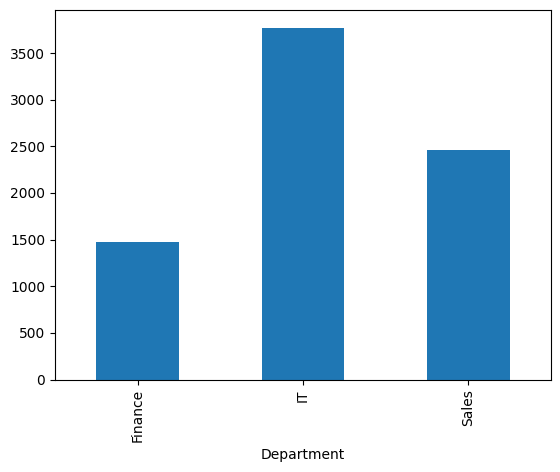

In [40]:
df.groupby("Department")["Total_Cost"].sum().plot(kind="bar")